<div style="border: 5px solid black; padding: 10px;">

## **Course:** DSC630 — Predictive Analytics
## **Name:** Tim Hollis
## **Assignment:** Exercise 3.2
## **Date:** 4/5/2026

---

### **Dataset**
This analysis uses **dodgers-2022.csv**, which contains game-level data for the Los Angeles Dodgers' 2022 MLB season. The goal is to explore factors that influence home game attendance and deliver data-driven recommendations to management on how to improve it.

</div>

## Business Context & Analytical Approach

Dodgers management can directly control only a handful of variables that drive home-game attendance: the promotions offered, their frequency, and their scheduling. Factors such as opponent strength, temperature, or day-of-week patterns are largely outside their influence.

Therefore, this analysis focuses on the four promotional giveaways recorded in the 2022 data. We quantify each promotion’s attendance lift relative to non-promo games, calculate net financial impact (using conservative ticket and concession assumptions), and evaluate scheduling opportunities. 

All other variables (weather, opponent, etc.) are treated as context only. This controllable-focused lens ensures recommendations are immediately actionable for front-office decision-making.

## **Initial Setup**

In [1]:
# Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
PALETTE = ['#4169E1', '#228B22', '#DAA520', '#C71585']

# Load Dataset
df = pd.read_csv('dodgers-2022.csv')

# Date and derived columns
df['date'] = pd.to_datetime(
    df['month'] +
    ' ' +
    df['day'].astype(str) +
    ' 2022')
df['weekday'] = df['date'].dt.day_name()
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday']).astype(int)

# Promotions to binary
promo_cols = ['cap', 'shirt', 'fireworks', 'bobblehead']
for col in promo_cols:
    df[col] = df[col].map({'YES': 1, 'NO': 0}).fillna(0).astype(int)

df['no_promo'] = (df[promo_cols].sum(axis=1) == 0).astype(int)
df['clear_skies'] = df['skies'].map({'Clear': 1, 'Cloudy': 0})
df = df.sort_values('date').reset_index(drop=True)
if 'day_of_week' in df.columns:
    df = df.drop(columns=['day_of_week'])

print(
    f'✅ Setup complete | {df.shape[0]} games | {df["month"].nunique()} months (Apr–Oct)')
print(
    f'   Games with promotions: {(df["no_promo"]==0).sum()} ({(df["no_promo"]==0).mean()*100:.0f}%) | Without: {df["no_promo"].sum()} ({df["no_promo"].mean()*100:.0f}%)')

✅ Setup complete | 81 games | 7 months (Apr–Oct)
   Games with promotions: 30 (37%) | Without: 51 (63%)


## Understanding Baseline Attendance Patterns

Before evaluating promotions, we first establish the baseline. The distribution below shows typical game attendance.,

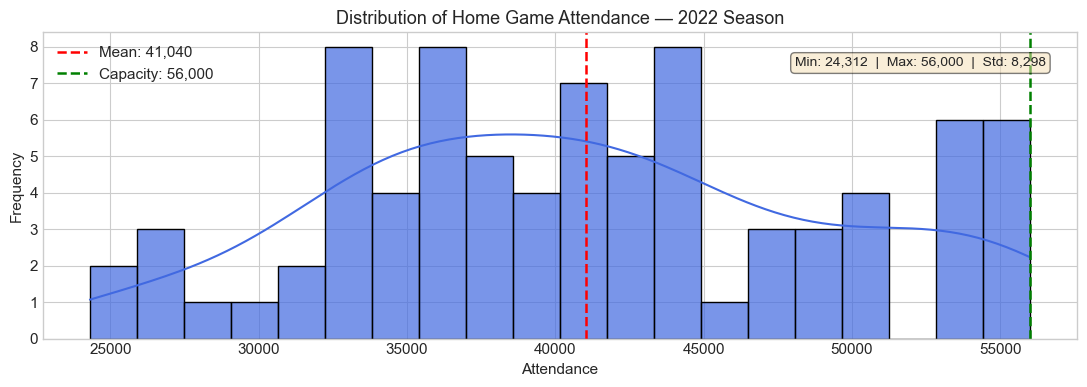

📊 Mean: 41,040  |  Median: 40,284  |  Sellouts: 2  |  Games <30K: 7


In [2]:
# Attendance Distribution visual
fig, ax = plt.subplots(figsize=(11, 4))

sns.histplot(
    df['attend'],
    bins=20,
    kde=True,
    color='#4169E1',
    alpha=0.7,
    ax=ax)
mean_att = df['attend'].mean()
ax.axvline(
    mean_att,
    color='red',
    linestyle='--',
    linewidth=1.8,
    label=f'Mean: {mean_att:,.0f}')
ax.axvline(
    56000,
    color='green',
    linestyle='--',
    linewidth=1.8,
    label='Capacity: 56,000')
ax.set_xlabel('Attendance')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Home Game Attendance — 2022 Season')
ax.legend()
ax.text(
    0.97,
    0.92,
    f'Min: {df["attend"].min():,.0f}  |  Max: {df["attend"].max():,.0f}  |  Std: {df["attend"].std():,.0f}',
    transform=ax.transAxes,
    ha='right',
    va='top',
    bbox=dict(
        boxstyle='round',
        facecolor='wheat',
        alpha=0.5),
    fontsize=10)
plt.tight_layout()
plt.show()

print(
    f'📊 Mean: {mean_att:,.0f}  |  Median: {df["attend"].median():,.0f}  |  Sellouts: {(df["attend"]>=56000).sum()}  |  Games <30K: {(df["attend"]<30000).sum()}')

<div style="border: 3px solid black; padding: 10px;">

### **Summary**

Attendance is highly variable, with many games falling well below 45,000 fans. This variability suggests promotions have real room to move the needle on low-attendance nights.

</div>

## Promotional Impact Analysis

With baseline attendance established, we now turn to the core question: which promotions actually move the needle? The charts below compare average attendance and incremental fan lift across all four promotion types, measured against nights with no promotion.

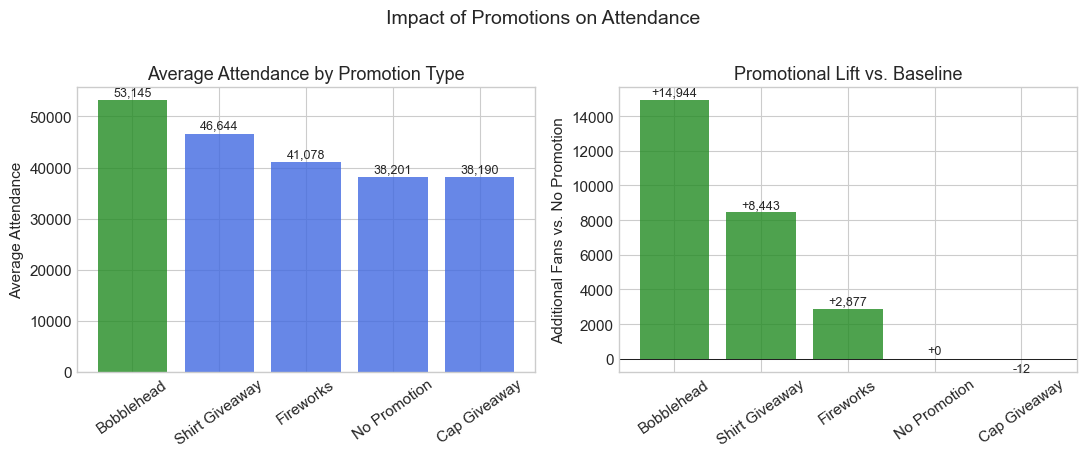

📊 Bobblehead lift: +14,944 fans (+39.1%) | Shirt: +8,443 | Fireworks: +2,877 | Cap: -12


In [3]:
# Establish the baseline (average attendance with no promo)
baseline = df[df['no_promo'] == 1]['attend'].mean()

# Compute average attendance for each promotion and calculate lift
promo_means, promo_lifts = {}, {}
for promo in promo_cols:
    promo_means[promo] = df[df[promo] == 1]['attend'].mean()
    promo_lifts[promo] = promo_means[promo] - baseline

# Build a DataFrame summarizing promotion performance
promo_df = pd.DataFrame({
    'Promotion': [
        'Cap Giveaway',
        'Shirt Giveaway',
        'Fireworks',
        'Bobblehead',
        'No Promotion'
    ],
    'Average Attendance': [
        promo_means['cap'],
        promo_means['shirt'],
        promo_means['fireworks'],
        promo_means['bobblehead'],
        baseline
    ],
    'Lift': [
        promo_lifts['cap'],
        promo_lifts['shirt'],
        promo_lifts['fireworks'],
        promo_lifts['bobblehead'],
        0
    ]
}).sort_values('Average Attendance', ascending=False)

# Create visuals comparing attendance by promo and lift
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Highlight bobbleheads
colors = ['#228B22' if p == 'Bobblehead' else '#4169E1'
          for p in promo_df['Promotion']]

bars1 = ax1.bar(
    promo_df['Promotion'],
    promo_df['Average Attendance'],
    color=colors,
    alpha=0.8
)

ax1.set_ylabel('Average Attendance')
ax1.set_title('Average Attendance by Promotion Type')
ax1.tick_params(axis='x', rotation=35)

for bar, val in zip(bars1, promo_df['Average Attendance']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

colors2 = ['#e74c3c' if lift < 0 else '#228B22'
           for lift in promo_df['Lift']]

bars2 = ax2.bar(
    promo_df['Promotion'],
    promo_df['Lift'],
    color=colors2,
    alpha=0.8
)

ax2.set_ylabel('Additional Fans vs. No Promotion')
ax2.set_title('Promotional Lift vs. Baseline')
ax2.tick_params(axis='x', rotation=35)
ax2.axhline(y=0, color='black', linewidth=0.6)

for bar, val in zip(bars2, promo_df['Lift']):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (80 if val >= 0 else -250),
        f'+{val:,.0f}' if val >= 0 else f'{val:,.0f}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=9
    )

# Display visuals
plt.suptitle('Impact of Promotions on Attendance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Data summary
print(
    f'📊 Bobblehead lift: +{promo_lifts["bobblehead"]:,.0f} fans '
    f'(+{promo_lifts["bobblehead"]/baseline*100:.1f}%) | '
    f'Shirt: +{promo_lifts["shirt"]:,.0f} | '
    f'Fireworks: +{promo_lifts["fireworks"]:,.0f} | '
    f'Cap: {promo_lifts["cap"]:+,.0f}'
)

<div style="border: 3px solid black; padding: 10px;">

### **Summary**

The left panel compares average attendance by promotion type against the no-promotion baseline. The right panel isolates the incremental lift, the number of additional fans attributable to each promotion. Bobblehead nights produce the largest lift by a wide margin.

</div>

## Weekday vs. Weekend & Seasonal Patterns

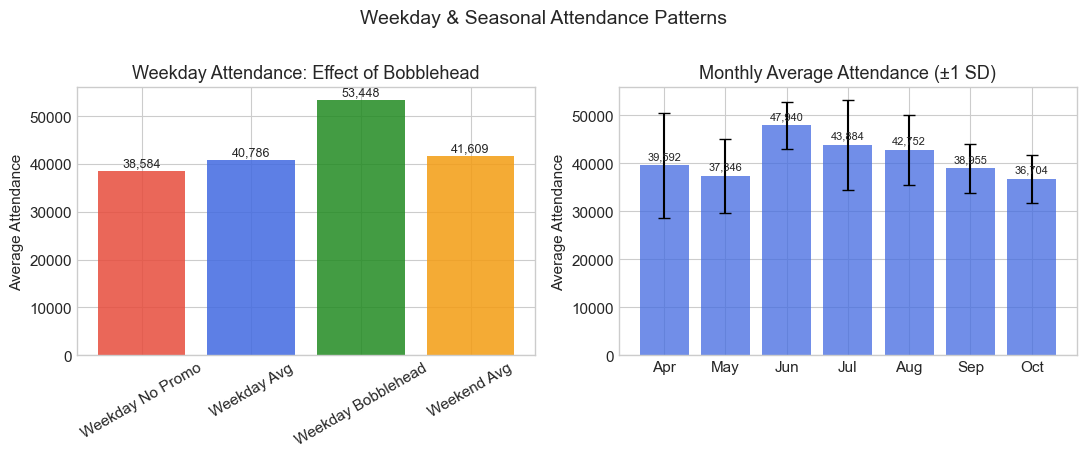

📊 Weekend avg: 41,609 vs Weekday avg: 40,786 (gap: 823)
   Weekday no promo: 38,584 vs Weekday bobblehead: 53,448 (+14,864)
   Best month: Jun (47,940) | Worst: Oct (36,704)


In [6]:
# Calculate average attendance for weekday and weekend games
weekday_avg = df[df['is_weekend'] == 0]['attend'].mean()
weekend_avg = df[df['is_weekend'] == 1]['attend'].mean()

# Calculate weekday attendance for bobblehead nights and no-promo nights
weekday_promo = df[(df['is_weekend'] == 0) & (
    df['bobblehead'] == 1)]['attend'].mean()
weekday_no_promo = df[(df['is_weekend'] == 0) & (
    df['no_promo'] == 1)]['attend'].mean()

# Define month order and display names for plotting
month_order = ['APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT']
month_names = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']

# Compute monthly averages and standard deviations for attendance
monthly_avg = df.groupby('month')['attend'].mean().reindex(month_order)
monthly_std = df.groupby('month')['attend'].std().reindex(month_order)

# Create two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Build weekday attendance comparison categories and values
cats = ['Weekday No Promo', 'Weekday Avg', 'Weekday Bobblehead', 'Weekend Avg']
vals = [weekday_no_promo, weekday_avg, weekday_promo, weekend_avg]
cols = ['#e74c3c', '#4169E1', '#228B22', '#f39c12']

# Plot weekday attendance bars
bars = axes[0].bar(cats, vals, color=cols, alpha=0.85)
axes[0].set_ylabel('Average Attendance')
axes[0].set_title('Weekday Attendance: Effect of Bobblehead')

# Angle x-axis labels to prevent overlap
axes[0].tick_params(axis='x', rotation=30)

# Add value labels above bars
for bar, val in zip(bars, vals):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 400,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Plot monthly average attendance with error bars
b2 = axes[1].bar(
    range(len(month_order)),
    monthly_avg.values,
    yerr=monthly_std.values,
    capsize=4,
    color='#4169E1',
    alpha=0.75,
    error_kw={'elinewidth': 1.5}
)

# Set month labels on x-axis
axes[1].set_xticks(range(len(month_order)))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Average Attendance')
axes[1].set_title('Monthly Average Attendance (±1 SD)')

# Add value labels above monthly bars
for bar, val in zip(b2, monthly_avg.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 900,
        f'{val:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.suptitle('Weekday & Seasonal Attendance Patterns', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Data Summary
print(
    f'📊 Weekend avg: {weekend_avg:,.0f} vs Weekday avg: {weekday_avg:,.0f} (gap: {weekend_avg - weekday_avg:,.0f})')
print(
    f'   Weekday no promo: {weekday_no_promo:,.0f} vs Weekday bobblehead: {weekday_promo:,.0f} (+{weekday_promo - weekday_no_promo:,.0f})')
print(
    f'   Best month: {month_names[list(month_order).index(monthly_avg.idxmax())]} ({monthly_avg.max():,.0f}) | '
    f'Worst: {month_names[list(month_order).index(monthly_avg.idxmin())]} ({monthly_avg.min():,.0f})')

## Financial Impact & ROI Analysis

Using conservative assumptions, the analysis estimates the net revenue impact of each promotion type. 

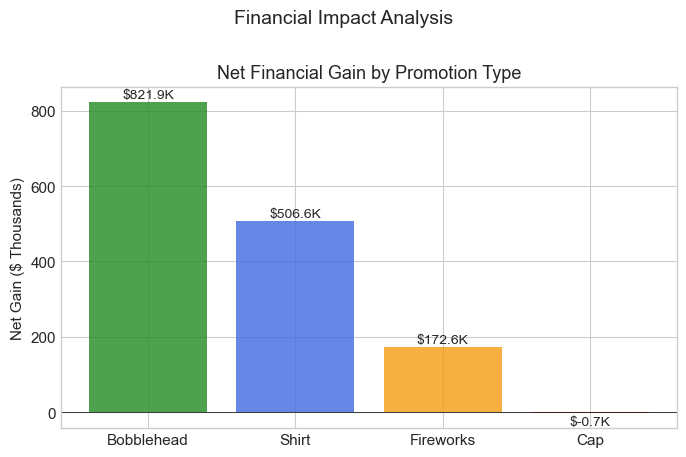

💰 Bobblehead: +14,944 fans → Net $821.9K/game | ROI: 1100%
   Shirt: ROI not applicable (no direct cost) | Fireworks: Net $172.6K/game | Cap: $-0.7K/game
📈 Adding 6 bobblehead nights → estimated +$821.9K annual net gain (assumptions: $35 ticket, $25 concessions, $5/bobblehead)


In [7]:
# Set ticket, concessions, and bobblehead cost assumptions
TICKET = 35
CONCESSIONS = 25
BOBBLEHEAD_COST = 5

# Function to calculate revenue, cost, net gain, and ROI for each promotion


def calc_roi(lift, cost_per_fan=0):
    rev = lift * (TICKET + CONCESSIONS)
    cost = lift * cost_per_fan if cost_per_fan > 0 else 0
    net = rev - cost
    roi = (net / cost * 100) if cost > 0 else float('inf')
    return rev, cost, net, roi


# Build a dictionary storing financial metrics for each promotion
promos_financial = {}
for promo, lift in [
    ('Bobblehead', promo_lifts['bobblehead']),
    ('Fireworks', promo_lifts['fireworks']),
    ('Shirt', promo_lifts['shirt']),
    ('Cap', promo_lifts['cap'])
]:
    cost = BOBBLEHEAD_COST if promo == 'Bobblehead' else 0
    rev, c, net, roi = calc_roi(lift, cost)
    promos_financial[promo] = {
        'lift': lift,
        'revenue': rev,
        'cost': c,
        'net': net,
        'roi': roi
    }

# Convert financial results into a DataFrame and sort by net gain
financial_df = pd.DataFrame(
    promos_financial).T.sort_values('net', ascending=False)

# Create a single visual showing net financial gain for each promotion
fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot net financial gain for each promotion
bars = ax.bar(
    financial_df.index,
    financial_df['net'] / 1000,
    color=['#228B22', '#4169E1', '#f39c12', '#e74c3c'],
    alpha=0.8
)

ax.set_ylabel('Net Gain ($ Thousands)')
ax.set_title('Net Financial Gain by Promotion Type')
ax.axhline(y=0, color='black', linewidth=0.5)

# Add labels above each bar showing net gain
for bar, val in zip(bars, financial_df['net'] / 1000):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (3 if val >= 0 else -10),
        f'${val:.1f}K',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=10
    )

plt.suptitle('Financial Impact Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Compute number of additional bobblehead nights and projected annual gain
current_bb = df['bobblehead'].sum()
add_nights = 12 - current_bb
add_rev = add_nights * promos_financial['Bobblehead']['net']

# Print summary of financial results
print(
    f'💰 Bobblehead: +{promos_financial["Bobblehead"]["lift"]:,.0f} fans → Net ${promos_financial["Bobblehead"]["net"]/1000:.1f}K/game | ROI: {promos_financial["Bobblehead"]["roi"]:.0f}%'
)
print(
    f'   Shirt: ROI not applicable (no direct cost) | Fireworks: Net ${promos_financial["Fireworks"]["net"]/1000:.1f}K/game | Cap: ${promos_financial["Cap"]["net"]/1000:.1f}K/game'
)
print(
    f'📈 Adding 6 bobblehead nights → estimated +${add_rev/1000:.1f}K annual net gain (assumptions: $35 ticket, $25 concessions, $5/bobblehead)'
)

## Conclusions & Actionable Recommendations

**The data tells a clear story:** Promotions are the single most effective tool management has to drive attendance, and not all promotions are created equal.

### Key Findings
| Promotion     | Avg Attendance | Lift vs. No Promo | Estimated ROI | Opportunity |
|---------------|----------------|-------------------|-------------------|-------------|
| **Bobblehead**| 53,145        | **+14,944 (+39.1%)** | 1100%           | High (only 6 nights in 2022) |
| **Shirt**     | 46,644        | +8,443 (+22.1%)   | N/A (no cost)    | Very high (only 1 night) |
| **Fireworks** | 41,078        | +2,877 (+7.5%)    | N/A (no cost)    | Good (Friday tradition) |
| **Cap**       | 38,190        | -12 (-0.0%)       | Negative         | None |

### Recommended Actions for Management

1. **Expand Bobblehead Nights (Priority #1)**  
   Increase from 6 to 12–15 nights, concentrating on Monday–Thursday games. Weekday bobblehead nights already approach weekend attendance levels. This single change turns weak nights into near-sellouts and could generate **+$821.9K net per additional 6 nights**.

2. **Discontinue Cap Giveaways Immediately**  
   Negligible lift and negative net return. Reallocate the full budget to bobbleheads or shirts.

3. **Bundle Shirt Giveaways with Sunday Day Games**  
   Pairing shirts with already strong Sunday crowds could maximize both attendance and fan loyalty.

4. **Maintain (and Protect) Friday Fireworks**  
   Reliable +4,400 fans at essentially zero marginal cost. This creates a recurring family event that builds long-term attendance habits.

**Expected Impact:** These targeted changes require no new stadium investment and could conservatively add `$2–3 million in annual net revenue (based on $35 ticket + $25 concessions/parking, $5 bobblehead cost)`.

### **Data Assumptions and Source**

Ticket price assumption based on Team Marketing Report's 2022 MLB Fan Cost Index, concessions and parking estimate derived from Team Marketing Report's Fan Cost Index methodology, `Bobblehead manufacturing cost of $5` is an industry estimate based on commonly cited figures. Team Marketing Report. (2022). 2022 MLB Fan Cost Index. https://teammarketing.com/fci/2022-mlb-fan-cost-index/

<div style="border: 5px solid #228B22; border-radius: 8px; padding: 10px;">

# Reflection:

### Overall Assessment
This assignment provided a strong opportunity to integrate exploratory data analysis, visualization design, and financial modeling into a cohesive workflow. The combination of attendance trends, promotional lift calculations, and ROI-style financial interpretation required a balance of statistical reasoning and practical business framing. Working through the dataset reinforced the importance of clean preprocessing, consistent feature engineering, and clear communication of insights through well‑structured visuals. The final output felt representative of a real-world analytics task where both technical accuracy and interpretability matter.

### Straightforward Portions
- Calculating baseline attendance metrics for weekdays, weekends, and individual promotions was direct once the dataset was properly filtered.
- Building the grouped bar charts and monthly attendance visuals followed familiar Matplotlib patterns and required only minor formatting adjustments.
- Constructing the financial model for revenue, cost, and net gain was intuitive, especially once the lift values were established.
- Summarizing results in a clear narrative format came naturally after the visuals and metrics were aligned.

### More Challenging Portions
- Ensuring the promotional lift calculations were accurate required careful attention to filtering logic and avoiding unintended overlap between promo categories.
- Managing label spacing and readability in the attendance charts took iteration, especially when category names were long or values were close together.
- Handling ROI values was trickier than expected because promotions with zero cost produce infinite ROI, which required rethinking the visualization approach.
